<a href="https://colab.research.google.com/github/ipm06aabhak-ai/ITA-assign-Aabha/blob/main/ppt%20lec2%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded
Shape: (100, 14)
   index                                                App        Category  \
0      0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN   
1      1                                Coloring book moana  ART_AND_DESIGN   
2      2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN   
3      3                              Sketch - Draw & Paint  ART_AND_DESIGN   
4      4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN   

   Rating  Reviews  Size     Installs  Type  Price Content Rating  \
0     4.1      159   19M      10,000+  Free      0       Everyone   
1     3.9      967   14M     500,000+  Free      0       Everyone   
2     4.7    87510  8.7M   5,000,000+  Free      0       Everyone   
3     4.5   215644   25M  50,000,000+  Free      0           Teen   
4     4.3      967  2.8M     100,000+  Free      0       Everyone   

                      Genres      Last Updated         Current Ver  \
0       

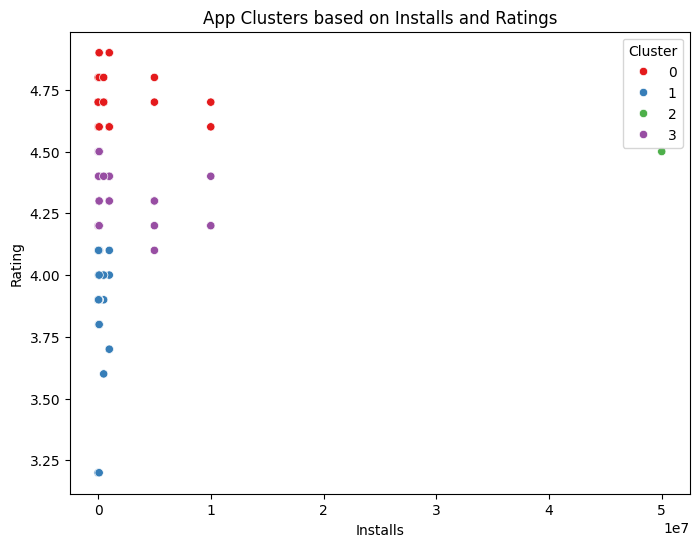


Apps with high downloads but low ratings:
Empty DataFrame
Columns: [App, Category, Installs, Rating]
Index: []

Model Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.90      1.00      0.95        18

    accuracy                           0.90        20
   macro avg       0.45      0.50      0.47        20
weighted avg       0.81      0.90      0.85        20


Key Insights:
• Clustering groups apps with similar popularity and ratings.
• Some apps have very high installs but poor ratings.
• This indicates user dissatisfaction despite popularity.
• Developers should focus on better performance and fewer intrusive ads.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [2]:
# ==============================
# Hybrid ML Assignment
# Dataset: Google Play Store Apps
# ==============================

# Install Excel support (safe even if already installed)
!pip install openpyxl

# Imports
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 1. Load Dataset
# ==============================

data = pd.read_excel("/content/Google playstore apps.xlsx")

print("Dataset loaded")
print("Shape:", data.shape)
print(data.head())


# ==============================
# 2. Basic Cleaning
# ==============================

# Remove rows without ratings
data = data.dropna(subset=['Rating'])

# Clean Installs column
data['Installs'] = data['Installs'].astype(str)
data['Installs'] = data['Installs'].str.replace('+','', regex=False)
data['Installs'] = data['Installs'].str.replace(',','', regex=False)
data['Installs'] = data['Installs'].astype(float)

# Clean Price column
data['Price'] = data['Price'].astype(str)
data['Price'] = data['Price'].str.replace('$','', regex=False)
data['Price'] = data['Price'].astype(float)

print("\nCleaned data preview:")
print(data[['App','Category','Rating','Installs','Price']].head())


# ==============================
# 3. Unsupervised Learning
# K-Means Clustering
# ==============================

features = data[['Rating','Installs','Price']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42)
data['Cluster'] = kmeans.fit_predict(scaled_features)

print("\nCluster counts:")
print(data['Cluster'].value_counts())


# ==============================
# 4. Cluster Visualization
# ==============================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=data['Installs'],
    y=data['Rating'],
    hue=data['Cluster'],
    palette='Set1'
)

plt.title("App Clusters based on Installs and Ratings")
plt.xlabel("Installs")
plt.ylabel("Rating")

plt.show()


# ==============================
# 5. Identify Problem Apps
# ==============================

problem_apps = data[(data['Installs'] > 1000000) & (data['Rating'] < 3.5)]

print("\nApps with high downloads but low ratings:")
print(problem_apps[['App','Category','Installs','Rating']].head())


# ==============================
# 6. Create Target Variable
# (for supervised learning)
# ==============================

# Treat high-rated apps as positive
data['Sentiment'] = data['Rating'].apply(lambda x: 1 if x >= 4 else 0)

X = data[['Installs','Price']]
y = data['Sentiment']


# ==============================
# 7. Train/Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ==============================
# 8. Supervised Learning
# Logistic Regression
# ==============================

model = LogisticRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)


# ==============================
# 9. Model Evaluation
# ==============================

print("\nModel Accuracy:", accuracy_score(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))


# ==============================
# 10. Business Insights
# ==============================

print("\nKey Insights:")
print("• Clustering groups apps with similar popularity and ratings.")
print("• Some apps have very high installs but poor ratings.")
print("• This indicates user dissatisfaction despite popularity.")
print("• Developers should focus on better performance and fewer intrusive ads.")